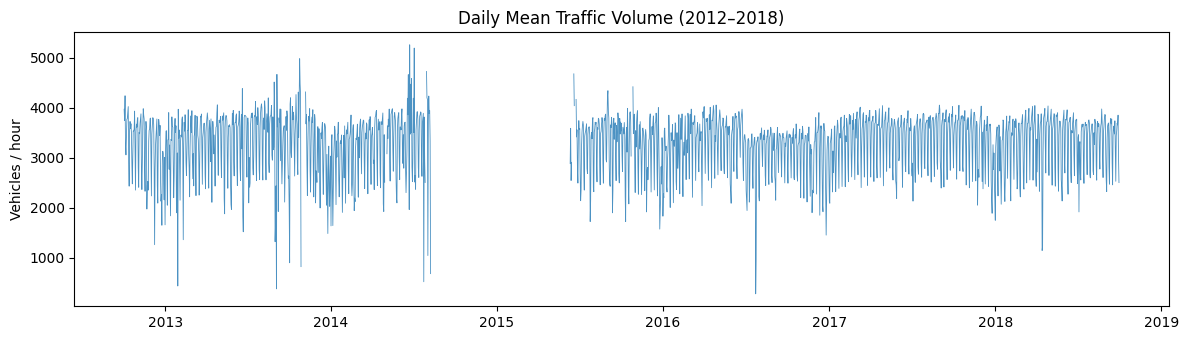

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

df = pd.read_excel('Metro_Traffic_Processed.xlsx', index_col=0, parse_dates=True)

daily = df['traffic_volume'].resample('D').mean()

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(daily.index, daily.values, linewidth=0.6, alpha=0.8)

ax.set_title('Daily Mean Traffic Volume (2012–2018)')
ax.set_ylabel('Vehicles / hour')

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('timeseries.png', dpi=150)
plt.show()

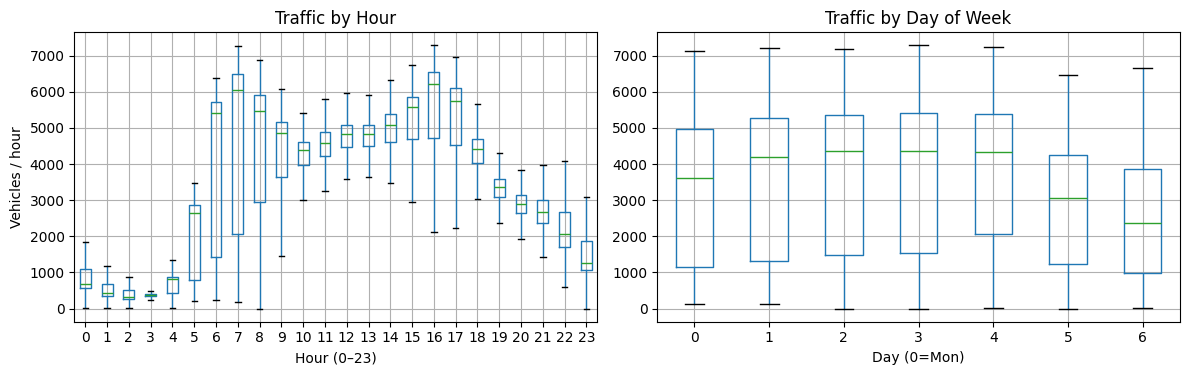

In [ ]:
df_plot = df.copy()
df_plot['hour'] = df_plot.index.hour
df_plot['dow']  = df_plot.index.dayofweek

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df_plot.boxplot(column='traffic_volume', by='hour',
                ax=axes[0], showfliers=False)
axes[0].set_title('Traffic by Hour')
axes[0].set_xlabel('Hour (0–23)')
axes[0].set_ylabel('Vehicles / hour')

df_plot.boxplot(column='traffic_volume', by='dow',
                ax=axes[1], showfliers=False)
axes[1].set_title('Traffic by Day of Week')
axes[1].set_xlabel('Day (0=Mon)')
axes[1].set_ylabel('')

plt.suptitle('')
plt.tight_layout()
plt.savefig('boxplots.png', dpi=150)
plt.show()

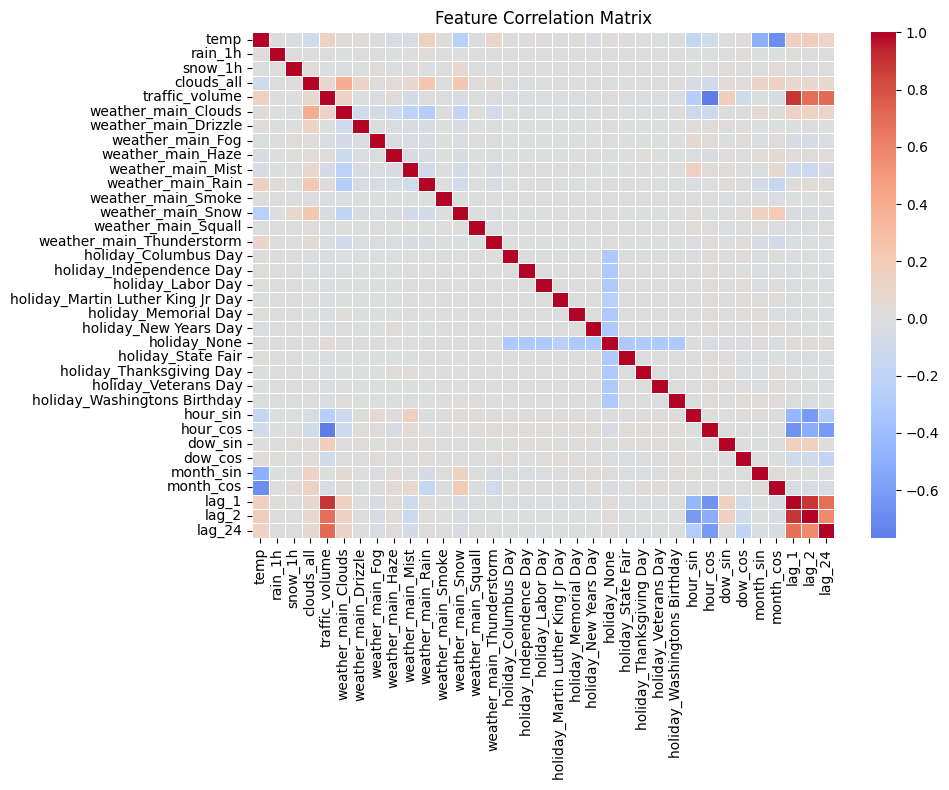

In [ ]:
import seaborn as sns

corr = df.corr()

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(corr,
            cmap='coolwarm',
            center=0,
            linewidths=0.5,
            ax=ax)

ax.set_title('Feature Correlation Matrix')

plt.tight_layout()
plt.savefig('heatmap.png', dpi=150)
plt.show()

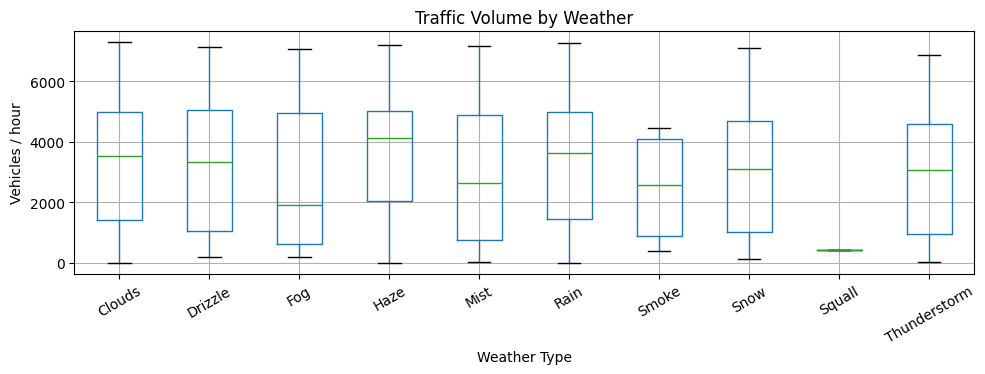

In [ ]:
weather_cols = [c for c in df.columns if c.startswith('weather_main_')]

df_weather = df.copy()

# Recover category from one-hot
df_weather['weather'] = df_weather[weather_cols].idxmax(axis=1)
df_weather['weather'] = df_weather['weather'].str.replace('weather_main_', '')

fig, ax = plt.subplots(figsize=(10, 4))

df_weather.boxplot(column='traffic_volume',
                   by='weather',
                   ax=ax,
                   showfliers=False,
                   rot=30)

ax.set_title('Traffic Volume by Weather')
ax.set_xlabel('Weather Type')
ax.set_ylabel('Vehicles / hour')

plt.suptitle('')
plt.tight_layout()
plt.savefig('weather.png', dpi=150)
plt.show()